# Two-Tower Recommendation System — Notebook v2

**Paradigma**: Implicit feedback (accepted/apply/click) + Sampled Softmax + In-batch Negatives  
**Text encoder**: Sentence-BERT `all-MiniLM-L6-v2` (384-dim, frozen, pre-computed)  
**Retrieval**: Brute-force dot product (cosine similarity) — catalog 43 scholarships  
**Metrics**: Recall@5, NDCG@5, MRR

---
Phases:
1. Setup & Imports
2. Load Data
3. Pre-compute Text Embeddings (skip if cache exists)
4. Structured Feature Encoding
5. Build TF Dataset
6. Tower Architecture
7. Sampled Softmax Loss
8. Training Loop (tf.GradientTape + TensorBoard)
9. Eval (Recall@5, NDCG@5, MRR) per epoch
10. Final Evaluation on Test Set
11. Inference Demo
12. Embedding Visualization (PCA)

## 1. Setup & Imports

In [1]:
import os, json, datetime
os.environ.setdefault("USE_TF", "0")          # sentence-transformers: PyTorch only
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"GPUs        : {tf.config.list_physical_devices('GPU')}")

TensorFlow  : 2.21.0
NumPy       : 2.4.4
Pandas      : 3.0.2
GPUs        : []


In [2]:
# ── Hyperparameters & Paths ──────────────────────────────────
DATA_DIR      = "./datasets_two_tower"
EMB_DIR       = f"{DATA_DIR}/text_embeddings"
LOG_DIR       = "./logs/two_tower_v2"
CHECKPOINT_DIR = "./checkpoints/two_tower_v2"

EMBEDDING_DIM  = 128       # student_emb / scholarship_emb output size
TEXT_EMB_DIM   = 384       # Sentence-BERT dimension
TEMPERATURE    = 0.1       # sampled softmax temperature
BATCH_SIZE     = 256
EPOCHS         = 20
LEARNING_RATE  = 1e-3

TOP_K          = 5         # Recall@K, NDCG@K

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Config OK")

Config OK


## 2. Load Data

In [3]:
feedback_df     = pd.read_csv(f"{DATA_DIR}/feedback.csv")
students_df     = pd.read_csv(f"{DATA_DIR}/students.csv")
scholarships_df = pd.read_csv(f"{DATA_DIR}/scholarships.csv")

# Parse JSON columns
for col in ["language_proficiency", "olympiad_subjects", "target_countries"]:
    students_df[col] = students_df[col].apply(json.loads)
for col in ["eligible_nationalities", "eligible_degree_levels",
            "eligible_high_school_tracks", "eligible_fields",
            "language_requirements", "selection_criteria"]:
    scholarships_df[col] = scholarships_df[col].apply(json.loads)

print(f"feedback.csv    : {len(feedback_df):,} rows")
print(f"students.csv    : {len(students_df):,} rows")
print(f"scholarships.csv: {len(scholarships_df):,} rows")
print(f"\nFeedback types:\n{feedback_df.feedback_type.value_counts()}")
feedback_df.head(3)

feedback.csv    : 100,000 rows
students.csv    : 20,000 rows
scholarships.csv: 43 rows

Feedback types:
feedback_type
click       48506
apply       44285
accepted     7209
Name: count, dtype: int64


,student_id,scholarship_id,feedback_type,timestamp
0,STU_000000,SCH_000002,click,2024-11-27T00:00:00Z
1,STU_000000,SCH_000008,accepted,2024-12-03T16:00:00Z
2,STU_000000,SCH_000032,accepted,2024-08-27T02:00:00Z


## 3. Pre-compute Text Embeddings

Skip jika cache `.npy` sudah ada. Jalankan `python precompute_embeddings.py` terlebih dahulu jika belum.

In [4]:
stu_emb_path = f"{EMB_DIR}/students.npy"
sch_emb_path = f"{EMB_DIR}/scholarships.npy"

if os.path.exists(stu_emb_path) and os.path.exists(sch_emb_path):
    student_text_emb     = np.load(stu_emb_path).astype(np.float32)  # (N_stu, 384)
    scholarship_text_emb = np.load(sch_emb_path).astype(np.float32)  # (N_sch, 384)
    print(f"Loaded from cache:")
    print(f"  student_text_emb    : {student_text_emb.shape}")
    print(f"  scholarship_text_emb: {scholarship_text_emb.shape}")
else:
    raise FileNotFoundError(
        f"Text embedding cache not found. Run: python precompute_embeddings.py"
    )

# Build lookup: student_id → embedding index (row order matches students.csv)
stu_id_to_idx = {sid: i for i, sid in enumerate(students_df["student_id"])}
sch_id_to_idx = {sid: i for i, sid in enumerate(scholarships_df["scholarship_id"])}

N_STU = len(students_df)
N_SCH = len(scholarships_df)
print(f"\nN_STU={N_STU:,}  N_SCH={N_SCH}")

Loaded from cache:
  student_text_emb    : (20000, 384)
  scholarship_text_emb: (43, 384)

N_STU=20,000  N_SCH=43


## 4. Structured Feature Encoding

One-hot, multi-hot, normalize — no `TextVectorization`.

In [5]:
# ── Vocabulary (fixed from synthetic data) ───────────────────
ALL_COUNTRIES = [
    "indonesia","malaysia","thailand","philippines","vietnam","singapore",
    "japan","south_korea","china","india",
    "france","germany","netherlands","sweden","uk","switzerland",
    "canada","usa","argentina","brazil","chile",
    "egypt","kenya","morocco","nigeria","south_africa",
    "australia","new_zealand",
]
ALL_TRACKS   = ["science","social_studies","languages","religion","vocational"]
ALL_FIELDS   = ["computer_science","engineering","medicine","business","economics",
                "law","education","arts_humanities","social_sciences","agriculture",
                "mathematics","physics","chemistry","biology"]
ALL_OLY_SUBJ = ["mathematics","physics","chemistry","biology","economics","geography",
                "computer_science","linguistics","astronomy","informatics",
                "history","english_language","business_studies"]
ALL_TIERS    = ["excellence","public_a","private_a","accredited_b",
                "accredited_c","unaccredited","unknown"]
ALL_INCOME   = ["very_low","low","middle","upper_middle","high"]
ALL_CAREERS  = ["academic","industry","government","ngo_npo","entrepreneurship","public_service"]
ALL_OLY_LVL  = ["none","school","city","provincial","national","international"]
ALL_LANG_TESTS = ["toefl","ielts","topik","jlpt","delf","hsk"]
ALL_DEGREE   = ["high_school","bachelors"]
ALL_REGIONS  = ["asia","europe","north_america","south_america","africa","oceania"]

def one_hot(val, vocab):
    v = [0.0] * len(vocab)
    if val in vocab:
        v[vocab.index(val)] = 1.0
    return v

def multi_hot(vals, vocab):
    v = [0.0] * len(vocab)
    for x in (vals or []):
        if x in vocab:
            v[vocab.index(x)] = 1.0
    return v

def norm_clip(val, lo, hi):
    return float(np.clip((val - lo) / (hi - lo + 1e-9), 0.0, 1.0))

print("Vocabs OK")

Vocabs OK


In [6]:
def encode_student(row) -> list:
    """Encode one student row → flat float vector."""
    feats = []
    feats += one_hot(row["nationality"], ALL_COUNTRIES)                     # 28
    feats += [norm_clip(row["age"], 16, 18)]                                 # 1
    feats += one_hot(row["high_school_track"], ALL_TRACKS)                  # 5
    feats += [norm_clip(row["overall_report_card_average"], 0, 100)]        # 1
    feats += [norm_clip(row["math_score"], 0, 100)]                         # 1
    feats += [norm_clip(row["english_score"], 0, 100)]                      # 1
    feats += [norm_clip(row["major_subject_average"], 0, 100)]              # 1
    # language proficiency: has_test + norm_score per test type             # 12
    lang_map = {lp["test_type"]: lp["score"] for lp in row["language_proficiency"]}
    score_max = {"toefl":120,"ielts":9,"topik":300,"jlpt":100,"delf":100,"hsk":300}
    for t in ALL_LANG_TESTS:
        if t in lang_map:
            feats += [1.0, norm_clip(lang_map[t], 0, score_max[t])]
        else:
            feats += [0.0, 0.0]
    feats += one_hot(row["olympiad_level"], ALL_OLY_LVL)                   # 6
    feats += multi_hot(row["olympiad_subjects"], ALL_OLY_SUBJ)             # 13
    feats += [norm_clip(row["leadership_experience_count"], 0, 10)]        # 1
    feats += [norm_clip(row["volunteer_experience_count"], 0, 15)]         # 1
    feats += [norm_clip(row["competition_wins_count"], 0, 10)]             # 1
    feats += one_hot(row["school_tier"], ALL_TIERS)                        # 7
    feats += one_hot(row["family_income_category"], ALL_INCOME)            # 5
    feats += [float(row["from_underrepresented_region"])]                   # 1
    feats += one_hot(row["intended_career_track"], ALL_CAREERS)            # 6
    feats += [float(row["willing_to_return_home"])]                         # 1
    feats += multi_hot(row["target_countries"], ALL_COUNTRIES)             # 28
    feats += [float(row["needs_full_funding"])]                             # 1
    feats += [float(row["can_self_fund_living"])]                           # 1
    return feats                                                             # total ≈ 122

def encode_scholarship(row) -> list:
    """Encode one scholarship row → flat float vector."""
    feats = []
    feats += multi_hot(row["eligible_nationalities"], ALL_COUNTRIES)        # 28
    feats += [norm_clip(row["min_age"], 14, 30),
              norm_clip(row["max_age"], 14, 30)]                            # 2
    feats += multi_hot(row["eligible_degree_levels"], ALL_DEGREE)          # 2
    feats += multi_hot(row["eligible_high_school_tracks"], ALL_TRACKS)     # 5
    feats += multi_hot(row["eligible_fields"], ALL_FIELDS)                 # 14
    feats += one_hot(row["preferred_school_tier"], ALL_TIERS)              # 7
    feats += [norm_clip(row["min_report_card_average"], 0, 100),
              norm_clip(row["min_major_subject_average"], 0, 100)]         # 2
    # language requirements: min_score per test type                        # 6
    req_map = {lr["test_type"]: lr["min_score"] for lr in row["language_requirements"]}
    score_max = {"toefl":120,"ielts":9,"topik":300,"jlpt":100,"delf":100,"hsk":300}
    for t in ALL_LANG_TESTS:
        feats += [norm_clip(req_map.get(t, 0), 0, score_max[t])]
    feats += [float(row["requires_financial_need"])]                        # 1
    feats += one_hot(row["max_family_income_category"], ALL_INCOME)        # 5
    feats += one_hot(row["host_country"], ALL_COUNTRIES)                   # 28
    feats += one_hot(row["host_region"], ALL_REGIONS)                      # 6
    sc = row["selection_criteria"]
    feats += [sc["academic"], sc["leadership"], sc["olympiad"],
              sc["extracurricular"], sc["essay"]]                           # 5
    feats += [float(row["funding_covers_tuition"]),
              float(row["funding_covers_living"]),
              float(row["funding_covers_airfare"]),
              float(row["funding_covers_insurance"])]                       # 4
    feats += [norm_clip(row["funding_monthly_stipend"], 0, 200_000)]       # 1
    feats += [float(row["funding_is_full_funding"])]                        # 1
    feats += [norm_clip(row["funding_coverage_count"], 0, 4)]              # 1
    ct = row.get("career_track_preference") or ""
    feats += one_hot(ct, ALL_CAREERS)                                      # 6
    feats += [float(row["requires_return_home_country"])]                   # 1
    return feats                                                             # total ≈ 125

# Pre-encode all students & scholarships
stu_struct = np.array([encode_student(r) for _, r in students_df.iterrows()],
                      dtype=np.float32)
sch_struct = np.array([encode_scholarship(r) for _, r in scholarships_df.iterrows()],
                      dtype=np.float32)

STU_STRUCT_DIM = stu_struct.shape[1]
SCH_STRUCT_DIM = sch_struct.shape[1]
print(f"stu_struct : {stu_struct.shape}  ({STU_STRUCT_DIM} structured features)")
print(f"sch_struct : {sch_struct.shape}  ({SCH_STRUCT_DIM} structured features)")

stu_struct : (20000, 122)  (122 structured features)
sch_struct : (43, 125)  (125 structured features)


## 5. Time-based Split + TF Dataset

Global time-based split: sort semua feedback by timestamp → 70% train / 15% val / 15% test.

In [7]:
feedback_sorted = feedback_df.sort_values("timestamp").reset_index(drop=True)
n = len(feedback_sorted)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_df = feedback_sorted.iloc[:n_train]
val_df   = feedback_sorted.iloc[n_train:n_train + n_val]
test_df  = feedback_sorted.iloc[n_train + n_val:]

print(f"Train : {len(train_df):,} rows  ({len(train_df)/n:.0%})")
print(f"Val   : {len(val_df):,} rows  ({len(val_df)/n:.0%})")
print(f"Test  : {len(test_df):,} rows  ({len(test_df)/n:.0%})")

Train : 70,000 rows  (70%)
Val   : 15,000 rows  (15%)
Test  : 15,000 rows  (15%)


In [8]:
def make_dataset(df: pd.DataFrame, shuffle: bool = False) -> tf.data.Dataset:
    """Build TF Dataset: each element = (stu_input, sch_input) tuple.
    
    stu_input = concat(structured, text_emb) shape=(STU_STRUCT_DIM + TEXT_EMB_DIM,)
    sch_input = concat(structured, text_emb) shape=(SCH_STRUCT_DIM + TEXT_EMB_DIM,)
    """
    stu_indices = np.array([stu_id_to_idx[sid] for sid in df["student_id"]], dtype=np.int32)
    sch_indices = np.array([sch_id_to_idx[sid] for sid in df["scholarship_id"]], dtype=np.int32)

    stu_feat = np.concatenate([stu_struct[stu_indices], student_text_emb[stu_indices]], axis=1)
    sch_feat = np.concatenate([sch_struct[sch_indices], scholarship_text_emb[sch_indices]], axis=1)

    ds = tf.data.Dataset.from_tensor_slices((stu_feat, sch_feat))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df,   shuffle=False)
test_ds  = make_dataset(test_df,  shuffle=False)

STU_INPUT_DIM = STU_STRUCT_DIM + TEXT_EMB_DIM
SCH_INPUT_DIM = SCH_STRUCT_DIM + TEXT_EMB_DIM

print(f"STU_INPUT_DIM = {STU_INPUT_DIM}  ({STU_STRUCT_DIM} struct + {TEXT_EMB_DIM} text)")
print(f"SCH_INPUT_DIM = {SCH_INPUT_DIM}  ({SCH_STRUCT_DIM} struct + {TEXT_EMB_DIM} text)")
print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")

STU_INPUT_DIM = 506  (122 struct + 384 text)
SCH_INPUT_DIM = 509  (125 struct + 384 text)
Train batches : 273
Val batches   : 58


## 6. Tower Architecture

```
StudentTower / ScholarshipTower:
  Input(struct + text_emb_384)
    → Dense(256, relu)
    → Dense(128, relu)
    → L2Normalize
    → emb (d=128)
```

No sigmoid output. No TextEncoderBlock. No shared embedding matrix.

In [9]:
class L2Normalize(tf.keras.layers.Layer):
    """Custom layer: L2-normalize embedding so dot product = cosine similarity."""
    def call(self, x):
        return tf.math.l2_normalize(x, axis=-1)


def build_tower(input_dim: int, name: str) -> tf.keras.Model:
    """Build a single tower: concat(struct, text_emb) → Dense(256) → Dense(128) → L2Norm."""
    inp = tf.keras.Input(shape=(input_dim,), name=f"{name}_input")
    x   = tf.keras.layers.Dense(256, activation="relu", name=f"{name}_dense_256")(inp)
    x   = tf.keras.layers.Dense(EMBEDDING_DIM, activation="relu", name=f"{name}_dense_128")(x)
    out = L2Normalize(name=f"{name}_l2norm")(x)
    return tf.keras.Model(inputs=inp, outputs=out, name=name)


student_tower     = build_tower(STU_INPUT_DIM, "student_tower")
scholarship_tower = build_tower(SCH_INPUT_DIM, "scholarship_tower")

student_tower.summary()
print()
scholarship_tower.summary()

Model: "student_tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ student_tower_input             │ (None, 506)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ student_tower_dense_256 (Dense) │ (None, 256)            │       129,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ student_tower_dense_128 (Dense) │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ student_tower_l2norm            │ (None, 128)            │             0 │
│ (L2Normalize)                   │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,688 (635.50 KB)

 Trainable params: 162,688 (635.50 KB)

 Non-trainable params: 0 (0.00 B)

Model: "scholarship_tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ scholarship_tower_input         │ (None, 509)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scholarship_tower_dense_256     │ (None, 256)            │       130,560 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scholarship_tower_dense_128     │ (None, 128)            │        32,896 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ scholarship_tower_l2norm        │ (None, 128)            │             0 │
│ (L2Normalize)                   │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,456 (638.50 KB)

 Trainable params: 163,456 (638.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Sampled Softmax Loss

```python
logits = (user_embs @ item_embs.T) / temperature   # (N, N)
labels = tf.eye(N)                                   # diagonal = positives
loss   = mean(softmax_cross_entropy(logits, labels))
```

In-batch negatives implicitly: setiap item di batch adalah negatif untuk semua query lain.

In [10]:
def sampled_softmax_loss(stu_emb: tf.Tensor, sch_emb: tf.Tensor,
                         temperature: float = TEMPERATURE) -> tf.Tensor:
    """Compute sampled softmax loss with in-batch negatives.
    
    Args:
        stu_emb: L2-normalized student embeddings, shape (N, d)
        sch_emb: L2-normalized scholarship embeddings, shape (N, d)
        temperature: softmax temperature (lower = sharper)
    
    Returns:
        Scalar loss value.
    """
    # logits[i, j] = cosine_sim(student_i, scholarship_j)
    logits = tf.matmul(stu_emb, sch_emb, transpose_b=True) / temperature   # (N, N)
    # Labels: identity matrix — student_i should match scholarship_i
    n = tf.shape(stu_emb)[0]
    labels = tf.eye(n)                                                        # (N, N)
    # Cross-entropy (over rows for student side, columns for scholarship side)
    loss_rows = tf.nn.softmax_cross_entropy_with_logits(labels=labels, logits=logits)
    loss_cols = tf.nn.softmax_cross_entropy_with_logits(labels=tf.transpose(labels),
                                                         logits=tf.transpose(logits))
    return tf.reduce_mean(loss_rows + loss_cols) / 2.0

# Quick sanity check
dummy_stu = tf.random.normal((4, EMBEDDING_DIM))
dummy_sch = tf.random.normal((4, EMBEDDING_DIM))
dummy_stu = tf.math.l2_normalize(dummy_stu, axis=-1)
dummy_sch = tf.math.l2_normalize(dummy_sch, axis=-1)
test_loss = sampled_softmax_loss(dummy_stu, dummy_sch)
print(f"Sampled softmax loss sanity check: {test_loss.numpy():.4f}  (expect ~ln(4) ≈ 1.39)")

Sampled softmax loss sanity check: 2.1147  (expect ~ln(4) ≈ 1.39)


## 8. Eval Metrics (Recall@K, NDCG@K, MRR)

In [11]:
def compute_retrieval_metrics(df: pd.DataFrame, k: int = TOP_K) -> dict:
    """Compute Recall@K, NDCG@K, MRR over a feedback split.

    For each student in the split:
      - positives = set of scholarships the student interacted with
      - retrieve = top-K scholarships by dot product
      - hit = overlap(retrieve, positives)

    Returns dict with mean Recall@K, NDCG@K, MRR.
    """
    # Pre-compute all scholarship embeddings once
    sch_feat_all = np.concatenate([sch_struct, scholarship_text_emb], axis=1)  # (N_SCH, d)
    sch_emb_all  = scholarship_tower(sch_feat_all, training=False).numpy()     # (N_SCH, 128)

    # Group by student
    student_groups = df.groupby("student_id")["scholarship_id"].apply(set).to_dict()

    recall_vals, ndcg_vals, mrr_vals = [], [], []

    for stu_id, pos_sch_ids in student_groups.items():
        if stu_id not in stu_id_to_idx:
            continue
        idx = stu_id_to_idx[stu_id]
        stu_feat = np.concatenate([stu_struct[[idx]], student_text_emb[[idx]]], axis=1)
        stu_emb  = student_tower(stu_feat, training=False).numpy()[0]  # (128,)

        # Brute-force dot product vs all 43 scholarships
        scores = sch_emb_all @ stu_emb                    # (N_SCH,)
        top_k_indices = np.argsort(-scores)[:k]           # descending
        retrieved_ids = set(scholarships_df.iloc[top_k_indices]["scholarship_id"])

        hits = retrieved_ids & pos_sch_ids
        recall = len(hits) / max(len(pos_sch_ids), 1)
        recall_vals.append(min(recall, 1.0))

        # NDCG@K — binary relevance
        dcg, idcg = 0.0, 0.0
        sch_id_list = list(scholarships_df.iloc[top_k_indices]["scholarship_id"])
        for rank, sid in enumerate(sch_id_list, start=1):
            if sid in pos_sch_ids:
                dcg += 1.0 / np.log2(rank + 1)
        ideal_hits = min(len(pos_sch_ids), k)
        for rank in range(1, ideal_hits + 1):
            idcg += 1.0 / np.log2(rank + 1)
        ndcg_vals.append(dcg / idcg if idcg > 0 else 0.0)

        # MRR
        mrr = 0.0
        for rank, sid in enumerate(sch_id_list, start=1):
            if sid in pos_sch_ids:
                mrr = 1.0 / rank
                break
        mrr_vals.append(mrr)

    return {
        f"Recall@{k}": float(np.mean(recall_vals)),
        f"NDCG@{k}":   float(np.mean(ndcg_vals)),
        "MRR":         float(np.mean(mrr_vals)),
        "n_students":  len(recall_vals),
    }

print("Metric functions ready.")

Metric functions ready.


## 9. Training Loop (tf.GradientTape + TensorBoard)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# TensorBoard writers
run_id    = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_writer = tf.summary.create_file_writer(f"{LOG_DIR}/{run_id}/train")
val_writer   = tf.summary.create_file_writer(f"{LOG_DIR}/{run_id}/val")

@tf.function
def train_step(stu_feat, sch_feat):
    with tf.GradientTape() as tape:
        stu_emb = student_tower(stu_feat, training=True)
        sch_emb = scholarship_tower(sch_feat, training=True)
        loss    = sampled_softmax_loss(stu_emb, sch_emb)
    grads = tape.gradient(loss, student_tower.trainable_variables
                                + scholarship_tower.trainable_variables)
    optimizer.apply_gradients(zip(grads, student_tower.trainable_variables
                                         + scholarship_tower.trainable_variables))
    return loss

def run_epoch(ds, training=True):
    losses = []
    for stu_feat, sch_feat in ds:
        if training:
            loss = train_step(stu_feat, sch_feat)
        else:
            stu_emb = student_tower(stu_feat, training=False)
            sch_emb = scholarship_tower(sch_feat, training=False)
            loss    = sampled_softmax_loss(stu_emb, sch_emb)
        losses.append(float(loss))
    return float(np.mean(losses))

print(f"TensorBoard logs → {LOG_DIR}/{run_id}/")
print("Start training with `%load_ext tensorboard` / `%tensorboard --logdir logs/two_tower_v2`")

TensorBoard logs → ./logs/two_tower_v2/20260527-211641/
Start training with `%load_ext tensorboard` / `%tensorboard --logdir logs/two_tower_v2`


In [13]:
history = {"epoch": [], "train_loss": [], "val_loss": [],
           f"val_Recall@{TOP_K}": [], f"val_NDCG@{TOP_K}": [], "val_MRR": []}

best_recall = 0.0
best_epoch  = 0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────
    train_loss = run_epoch(train_ds, training=True)
    with train_writer.as_default():
        tf.summary.scalar("loss", train_loss, step=epoch)

    # ── Val loss ───────────────────────────────────────────
    val_loss = run_epoch(val_ds, training=False)
    with val_writer.as_default():
        tf.summary.scalar("loss", val_loss, step=epoch)

    # ── Retrieval metrics on val (every epoch) ─────────────
    metrics = compute_retrieval_metrics(val_df)
    with val_writer.as_default():
        for k, v in metrics.items():
            if isinstance(v, float):
                tf.summary.scalar(k, v, step=epoch)

    # ── Bookkeeping ────────────────────────────────────────
    recall = metrics[f"Recall@{TOP_K}"]
    if recall > best_recall:
        best_recall = recall
        best_epoch  = epoch
        student_tower.save_weights(f"{CHECKPOINT_DIR}/student_tower.weights.h5")
        scholarship_tower.save_weights(f"{CHECKPOINT_DIR}/scholarship_tower.weights.h5")

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history[f"val_Recall@{TOP_K}"].append(recall)
    history[f"val_NDCG@{TOP_K}"].append(metrics[f"NDCG@{TOP_K}"])
    history["val_MRR"].append(metrics["MRR"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"Recall@{TOP_K}={recall:.4f} NDCG@{TOP_K}={metrics[f'NDCG@{TOP_K}']:.4f} "
          f"MRR={metrics['MRR']:.4f}"
          + (" ← best" if epoch == best_epoch else ""))

print(f"\nBest Recall@{TOP_K}={best_recall:.4f} at epoch {best_epoch}")

Epoch 01/20 | train_loss=5.4489 val_loss=5.4042 | Recall@5=0.2947 NDCG@5=0.2010 MRR=0.1929 ← best
Epoch 02/20 | train_loss=5.3907 val_loss=5.3846 | Recall@5=0.3062 NDCG@5=0.2078 MRR=0.1979 ← best
Epoch 03/20 | train_loss=5.3668 val_loss=5.3791 | Recall@5=0.3106 NDCG@5=0.2112 MRR=0.2008 ← best
Epoch 04/20 | train_loss=5.3490 val_loss=5.3792 | Recall@5=0.3095 NDCG@5=0.2097 MRR=0.1995
Epoch 05/20 | train_loss=5.3327 val_loss=5.3875 | Recall@5=0.3054 NDCG@5=0.2053 MRR=0.1939
Epoch 06/20 | train_loss=5.3161 val_loss=5.4002 | Recall@5=0.3068 NDCG@5=0.2066 MRR=0.1954
Epoch 07/20 | train_loss=5.2971 val_loss=5.4228 | Recall@5=0.2846 NDCG@5=0.1883 MRR=0.1769
Epoch 08/20 | train_loss=5.2775 val_loss=5.4475 | Recall@5=0.2896 NDCG@5=0.1899 MRR=0.1774
Epoch 09/20 | train_loss=5.2532 val_loss=5.4612 | Recall@5=0.2869 NDCG@5=0.1887 MRR=0.1762
Epoch 10/20 | train_loss=5.2338 val_loss=5.4721 | Recall@5=0.2788 NDCG@5=0.1824 MRR=0.1707
Epoch 11/20 | train_loss=5.2131 val_loss=5.4999 | Recall@5=0.2700 NDC

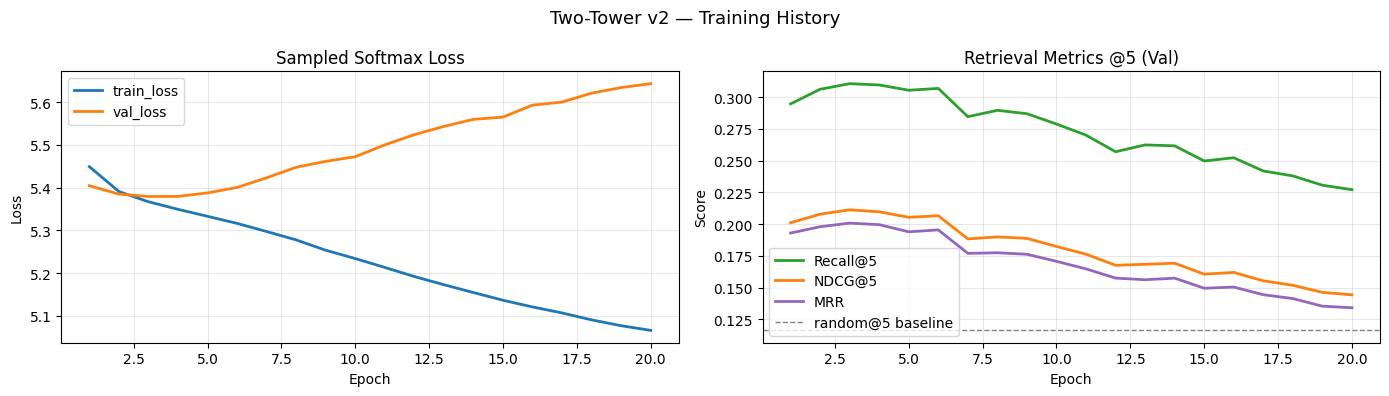

In [14]:
# ── Loss curve ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="train_loss", linewidth=2)
axes[0].plot(history["epoch"], history["val_loss"],   label="val_loss",   linewidth=2)
axes[0].set_title("Sampled Softmax Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history[f"val_Recall@{TOP_K}"],
             label=f"Recall@{TOP_K}", linewidth=2, color="tab:green")
axes[1].plot(history["epoch"], history[f"val_NDCG@{TOP_K}"],
             label=f"NDCG@{TOP_K}",  linewidth=2, color="tab:orange")
axes[1].plot(history["epoch"], history["val_MRR"],
             label="MRR", linewidth=2, color="tab:purple")
axes[1].axhline(5/43, color="gray", linestyle="--", linewidth=1, label="random@5 baseline")
axes[1].set_title(f"Retrieval Metrics @{TOP_K} (Val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Two-Tower v2 — Training History", fontsize=13)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/training_history.png", dpi=120)
plt.show()

## 10. Final Evaluation on Test Set

Load best checkpoint, evaluate on test split.

In [15]:
# Load best weights
student_tower.load_weights(f"{CHECKPOINT_DIR}/student_tower.weights.h5")
scholarship_tower.load_weights(f"{CHECKPOINT_DIR}/scholarship_tower.weights.h5")
print(f"Loaded best checkpoint from epoch {best_epoch}")

# Test set metrics
test_metrics = compute_retrieval_metrics(test_df)
print("\n── Test Set Evaluation ──────────────────────────────")
for k, v in test_metrics.items():
    if isinstance(v, float):
        target = {"Recall@5": 0.40, "NDCG@5": 0.30}.get(k, None)
        tag = ""
        if target is not None:
            tag = "✓ PASS" if v >= target else f"✗ BELOW target ({target})"
        print(f"  {k:<14}: {v:.4f}  {tag}")
    else:
        print(f"  {k:<14}: {v}")

# Also compute Recall@10 for supplementary info
test_metrics_10 = compute_retrieval_metrics(test_df, k=10)
print(f"\n  Recall@10      : {test_metrics_10['Recall@10']:.4f}")
print(f"  NDCG@10        : {test_metrics_10['NDCG@10']:.4f}")

Loaded best checkpoint from epoch 3

── Test Set Evaluation ──────────────────────────────
  Recall@5      : 0.3076  ✗ BELOW target (0.4)
  NDCG@5        : 0.2089  ✗ BELOW target (0.3)
  MRR           : 0.1979  
  n_students    : 11084

  Recall@10      : 0.4188
  NDCG@10        : 0.2472


## 11. Inference Demo

Top-5 recommendations untuk 3 student profile berbeda.

In [16]:
# Pre-compute all 43 scholarship embeddings (used once for inference)
sch_feat_all = np.concatenate([sch_struct, scholarship_text_emb], axis=1)
sch_emb_all  = scholarship_tower(sch_feat_all, training=False).numpy()  # (43, 128)
print(f"Scholarship embeddings pre-computed: {sch_emb_all.shape}")


def recommend(student_id: str, k: int = 5) -> pd.DataFrame:
    """Return top-k scholarship recommendations for a student."""
    if student_id not in stu_id_to_idx:
        raise ValueError(f"Unknown student_id: {student_id}")
    idx = stu_id_to_idx[student_id]
    stu_feat = np.concatenate([stu_struct[[idx]], student_text_emb[[idx]]], axis=1)
    stu_emb  = student_tower(stu_feat, training=False).numpy()[0]
    scores   = sch_emb_all @ stu_emb                           # (43,)
    top_idx  = np.argsort(-scores)[:k]
    result   = scholarships_df.iloc[top_idx][["scholarship_id","name","host_country"]].copy()
    result["score"] = scores[top_idx].round(4)
    result.index    = range(1, k + 1)
    return result


# ── Demo: 3 distinct profiles ─────────────────────────────────
# Pick students by nationality filters for visual diversity
demo_ids = {}
for nationality in ["indonesia", "japan", "usa"]:
    mask = students_df["nationality"] == nationality
    candidates = students_df[mask]["student_id"].tolist()
    if candidates:
        demo_ids[nationality] = candidates[0]

for nat, sid in demo_ids.items():
    stu_row = students_df[students_df["student_id"] == sid].iloc[0]
    print(f"\n{'='*58}")
    print(f"Student: {sid}  nationality={nat}  "
          f"track={stu_row['high_school_track']}  "
          f"gpa={stu_row['overall_report_card_average']:.1f}")
    print(f"{'='*58}")
    print(recommend(sid, k=5).to_string())

Scholarship embeddings pre-computed: (43, 128)

Student: STU_000002  nationality=indonesia  track=social_studies  gpa=76.7
  scholarship_id                                                 name host_country   score
1     SCH_000031               Moroccan Government Scholarship (AMCI)      morocco  0.5052
2     SCH_000040  Fudan University International Scholarship (Type B)        china  0.4849
3     SCH_000028                 Polish Government Scholarship (NAWA)      germany  0.4848
4     SCH_000000       Beasiswa Indonesia Maju (BIM) — S1 Luar Negeri           uk  0.4811
5     SCH_000027                   Czech Government Scholarship (DZS)      germany  0.4760

Student: STU_000033  nationality=japan  track=science  gpa=80.1
  scholarship_id                                               name host_country   score
1     SCH_000000     Beasiswa Indonesia Maju (BIM) — S1 Luar Negeri           uk  0.5062
2     SCH_000013  JPA Malaysia Overseas Scholarship (Undergraduate)           uk  0.4965

## 12. Embedding Visualization (PCA)

Proyeksi `student_emb` + `scholarship_emb` ke 2D via PCA.

PCA explained variance: 42.99%


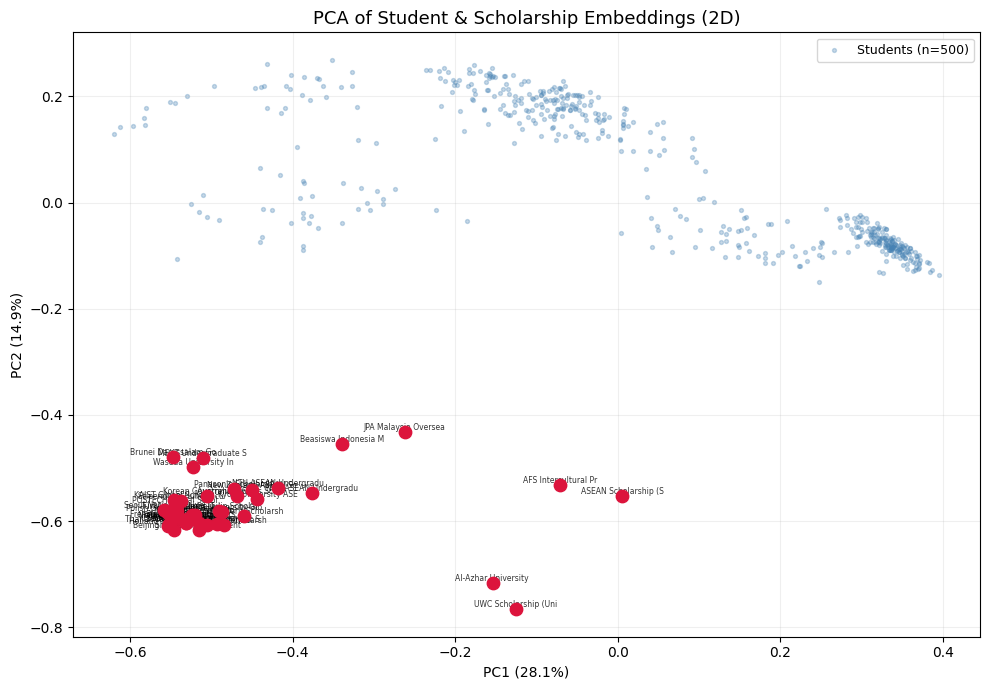

In [17]:
from sklearn.decomposition import PCA

# Sample 500 students for visibility
SAMPLE_N = 500
np.random.seed(SEED)
sample_idx = np.random.choice(N_STU, size=SAMPLE_N, replace=False)
stu_feat_sample = np.concatenate([stu_struct[sample_idx], student_text_emb[sample_idx]], axis=1)
stu_emb_sample  = student_tower(stu_feat_sample, training=False).numpy()  # (500, 128)

# Combine student + scholarship embeddings for PCA
all_embs  = np.vstack([stu_emb_sample, sch_emb_all])
labels    = ["student"] * SAMPLE_N + ["scholarship"] * N_SCH

pca  = PCA(n_components=2, random_state=SEED)
proj = pca.fit_transform(all_embs)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(10, 7))
# Students
ax.scatter(proj[:SAMPLE_N, 0], proj[:SAMPLE_N, 1],
           c="steelblue", alpha=0.3, s=8, label=f"Students (n={SAMPLE_N})")
# Scholarships — larger + labeled
for i in range(N_SCH):
    ax.scatter(proj[SAMPLE_N + i, 0], proj[SAMPLE_N + i, 1],
               c="crimson", s=80, zorder=5)
    name_short = scholarships_df.iloc[i]["name"][:20]
    ax.annotate(name_short, (proj[SAMPLE_N + i, 0], proj[SAMPLE_N + i, 1]),
                fontsize=5.5, alpha=0.8, ha="center", va="bottom")

ax.set_title("PCA of Student & Scholarship Embeddings (2D)", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/embedding_pca.png", dpi=130)
plt.show()

## 13. Phase 4 — Sample Weighting Ablation

**Hipotesis**: Memberi bobot lebih tinggi pada `accepted` (5×) dan `apply` (2×) dibanding `click` (1×) akan mendorong model fokus pada sinyal paling informatif.

| feedback_type | weight |
|---|---|
| accepted | 5.0 |
| apply | 2.0 |
| click | 1.0 |

Reset tower weights → rebuild dataset dengan bobot → training ulang → bandingkan dengan Phase 3.

In [18]:
# ── Phase 4 Setup ──────────────────────────────────────────────
FEEDBACK_WEIGHTS = {"accepted": 5.0, "apply": 2.0, "click": 1.0}

# Reset towers with fresh random weights (re-run build_tower from Cell 6)
student_tower_p4     = build_tower(STU_INPUT_DIM, "student_tower_p4")
scholarship_tower_p4 = build_tower(SCH_INPUT_DIM, "scholarship_tower_p4")
optimizer_p4         = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
print("Towers reset with fresh weights.")


# ── Weighted Dataset ────────────────────────────────────────────
def make_dataset_weighted(df: pd.DataFrame, shuffle: bool = False) -> tf.data.Dataset:
    """Same as make_dataset but yields (stu_feat, sch_feat, weight) triples."""
    stu_indices = np.array([stu_id_to_idx[sid] for sid in df["student_id"]], dtype=np.int32)
    sch_indices = np.array([sch_id_to_idx[sid] for sid in df["scholarship_id"]], dtype=np.int32)
    weights     = np.array([FEEDBACK_WEIGHTS[ft] for ft in df["feedback_type"]], dtype=np.float32)

    stu_feat = np.concatenate([stu_struct[stu_indices], student_text_emb[stu_indices]], axis=1)
    sch_feat = np.concatenate([sch_struct[sch_indices], scholarship_text_emb[sch_indices]], axis=1)

    ds = tf.data.Dataset.from_tensor_slices((stu_feat, sch_feat, weights))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_w = make_dataset_weighted(train_df, shuffle=True)
val_ds_w   = make_dataset_weighted(val_df,   shuffle=False)
test_ds_w  = make_dataset_weighted(test_df,  shuffle=False)
print(f"Weighted datasets ready  (train={len(train_ds_w)} batches)")


# ── Weighted Loss ───────────────────────────────────────────────
def sampled_softmax_loss_weighted(stu_emb: tf.Tensor, sch_emb: tf.Tensor,
                                   weights: tf.Tensor,
                                   temperature: float = TEMPERATURE) -> tf.Tensor:
    """Sampled softmax loss with per-sample weights.

    weights shape: (N,) — one scalar per pair in batch.
    Normalized to mean=1 inside the function so the loss scale is stable.
    """
    logits = tf.matmul(stu_emb, sch_emb, transpose_b=True) / temperature  # (N, N)
    n      = tf.shape(stu_emb)[0]
    labels = tf.eye(n)

    loss_rows = tf.nn.softmax_cross_entropy_with_logits(labels=labels, logits=logits)
    loss_cols = tf.nn.softmax_cross_entropy_with_logits(
        labels=tf.transpose(labels), logits=tf.transpose(logits))

    per_sample = (loss_rows + loss_cols) / 2.0           # (N,)
    w_norm     = weights / (tf.reduce_mean(weights) + 1e-9)   # normalize so mean=1
    return tf.reduce_mean(w_norm * per_sample)

# Sanity check
dummy_w = tf.constant([5.0, 2.0, 1.0, 2.0])
dummy_loss = sampled_softmax_loss_weighted(dummy_stu, dummy_sch, dummy_w)
print(f"Weighted loss sanity check: {dummy_loss.numpy():.4f}")

Towers reset with fresh weights.
Weighted datasets ready  (train=273 batches)
Weighted loss sanity check: 2.2379


In [19]:
# ── Phase 4 Training Loop ───────────────────────────────────────
@tf.function
def train_step_weighted(stu_feat, sch_feat, weights):
    with tf.GradientTape() as tape:
        stu_emb = student_tower_p4(stu_feat, training=True)
        sch_emb = scholarship_tower_p4(sch_feat, training=True)
        loss    = sampled_softmax_loss_weighted(stu_emb, sch_emb, weights)
    grads = tape.gradient(loss, student_tower_p4.trainable_variables
                                + scholarship_tower_p4.trainable_variables)
    optimizer_p4.apply_gradients(zip(grads, student_tower_p4.trainable_variables
                                           + scholarship_tower_p4.trainable_variables))
    return loss


def run_epoch_weighted(ds, training=True):
    losses = []
    for stu_feat, sch_feat, weights in ds:
        if training:
            loss = train_step_weighted(stu_feat, sch_feat, weights)
        else:
            stu_emb = student_tower_p4(stu_feat, training=False)
            sch_emb = scholarship_tower_p4(sch_feat, training=False)
            loss    = sampled_softmax_loss_weighted(stu_emb, sch_emb, weights)
        losses.append(float(loss))
    return float(np.mean(losses))


def compute_retrieval_metrics_p4(df: pd.DataFrame, k: int = TOP_K) -> dict:
    """Same as compute_retrieval_metrics but uses Phase 4 towers."""
    sch_feat_all = np.concatenate([sch_struct, scholarship_text_emb], axis=1)
    sch_emb_all  = scholarship_tower_p4(sch_feat_all, training=False).numpy()

    student_groups = df.groupby("student_id")["scholarship_id"].apply(set).to_dict()
    recall_vals, ndcg_vals, mrr_vals = [], [], []

    for stu_id, pos_sch_ids in student_groups.items():
        if stu_id not in stu_id_to_idx:
            continue
        idx = stu_id_to_idx[stu_id]
        stu_feat = np.concatenate([stu_struct[[idx]], student_text_emb[[idx]]], axis=1)
        stu_emb  = student_tower_p4(stu_feat, training=False).numpy()[0]

        scores      = sch_emb_all @ stu_emb
        top_k_idx   = np.argsort(-scores)[:k]
        retrieved   = set(scholarships_df.iloc[top_k_idx]["scholarship_id"])
        hits        = retrieved & pos_sch_ids

        recall_vals.append(min(len(hits) / max(len(pos_sch_ids), 1), 1.0))

        dcg, idcg = 0.0, 0.0
        for rank, sid in enumerate(scholarships_df.iloc[top_k_idx]["scholarship_id"], 1):
            if sid in pos_sch_ids:
                dcg += 1.0 / np.log2(rank + 1)
        for rank in range(1, min(len(pos_sch_ids), k) + 1):
            idcg += 1.0 / np.log2(rank + 1)
        ndcg_vals.append(dcg / idcg if idcg > 0 else 0.0)

        mrr = 0.0
        for rank, sid in enumerate(scholarships_df.iloc[top_k_idx]["scholarship_id"], 1):
            if sid in pos_sch_ids:
                mrr = 1.0 / rank
                break
        mrr_vals.append(mrr)

    return {
        f"Recall@{k}": float(np.mean(recall_vals)),
        f"NDCG@{k}":   float(np.mean(ndcg_vals)),
        "MRR":         float(np.mean(mrr_vals)),
        "n_students":  len(recall_vals),
    }


# ── Train Phase 4 ───────────────────────────────────────────────
history_p4 = {"epoch": [], "train_loss": [], "val_loss": [],
               f"val_Recall@{TOP_K}": [], f"val_NDCG@{TOP_K}": [], "val_MRR": []}

best_recall_p4 = 0.0
best_epoch_p4  = 0
CHECKPOINT_DIR_P4 = f"{CHECKPOINT_DIR}_p4"
os.makedirs(CHECKPOINT_DIR_P4, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch_weighted(train_ds_w, training=True)
    val_loss   = run_epoch_weighted(val_ds_w,   training=False)
    metrics    = compute_retrieval_metrics_p4(val_df)
    recall     = metrics[f"Recall@{TOP_K}"]

    if recall > best_recall_p4:
        best_recall_p4 = recall
        best_epoch_p4  = epoch
        student_tower_p4.save_weights(f"{CHECKPOINT_DIR_P4}/student_tower.weights.h5")
        scholarship_tower_p4.save_weights(f"{CHECKPOINT_DIR_P4}/scholarship_tower.weights.h5")

    history_p4["epoch"].append(epoch)
    history_p4["train_loss"].append(train_loss)
    history_p4["val_loss"].append(val_loss)
    history_p4[f"val_Recall@{TOP_K}"].append(recall)
    history_p4[f"val_NDCG@{TOP_K}"].append(metrics[f"NDCG@{TOP_K}"])
    history_p4["val_MRR"].append(metrics["MRR"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"Recall@{TOP_K}={recall:.4f} NDCG@{TOP_K}={metrics[f'NDCG@{TOP_K}']:.4f} "
          f"MRR={metrics['MRR']:.4f}"
          + (" ← best" if epoch == best_epoch_p4 else ""))

print(f"\nBest Recall@{TOP_K}={best_recall_p4:.4f} at epoch {best_epoch_p4}")

Epoch 01/20 | train_loss=5.3856 val_loss=5.3307 | Recall@5=0.3053 NDCG@5=0.2114 MRR=0.2040 ← best
Epoch 02/20 | train_loss=5.3102 val_loss=5.3084 | Recall@5=0.3079 NDCG@5=0.2127 MRR=0.2043 ← best
Epoch 03/20 | train_loss=5.2811 val_loss=5.3012 | Recall@5=0.3168 NDCG@5=0.2200 MRR=0.2112 ← best
Epoch 04/20 | train_loss=5.2572 val_loss=5.3012 | Recall@5=0.3126 NDCG@5=0.2156 MRR=0.2064
Epoch 05/20 | train_loss=5.2343 val_loss=5.3104 | Recall@5=0.3109 NDCG@5=0.2131 MRR=0.2040
Epoch 06/20 | train_loss=5.2097 val_loss=5.3390 | Recall@5=0.3078 NDCG@5=0.2098 MRR=0.2002
Epoch 07/20 | train_loss=5.1846 val_loss=5.3633 | Recall@5=0.3024 NDCG@5=0.2038 MRR=0.1931
Epoch 08/20 | train_loss=5.1576 val_loss=5.3833 | Recall@5=0.3004 NDCG@5=0.2022 MRR=0.1914
Epoch 09/20 | train_loss=5.1286 val_loss=5.3987 | Recall@5=0.2923 NDCG@5=0.1969 MRR=0.1863
Epoch 10/20 | train_loss=5.1020 val_loss=5.4441 | Recall@5=0.2883 NDCG@5=0.1915 MRR=0.1800
Epoch 11/20 | train_loss=5.0793 val_loss=5.4526 | Recall@5=0.2906 NDC

Loaded Phase 4 best checkpoint (epoch 3)

╔══════════════════════════════════════════════════════════════╗
║           Phase 3 vs Phase 4 — Test Set Comparison          ║
╠══════════════════════╦══════════╦══════════╦════════════════╣
║ Metric               ║ Phase 3  ║ Phase 4  ║ Delta          ║
╠══════════════════════╬══════════╬══════════╬════════════════╣
║ Recall@5  (target≥0.4) ║ 0.3076   ║ 0.3125   ║ +0.0049 ✗        ║
║ NDCG@5    (target≥0.3) ║ 0.2089   ║ 0.2159   ║ +0.0070 ✗        ║
║ MRR                  ║ 0.1979   ║ 0.2067   ║ +0.0088          ║
║ Recall@10            ║ 0.4188   ║ 0.4334   ║ +0.0147 ✓        ║
╚══════════════════════╩══════════╩══════════╩════════════════╝


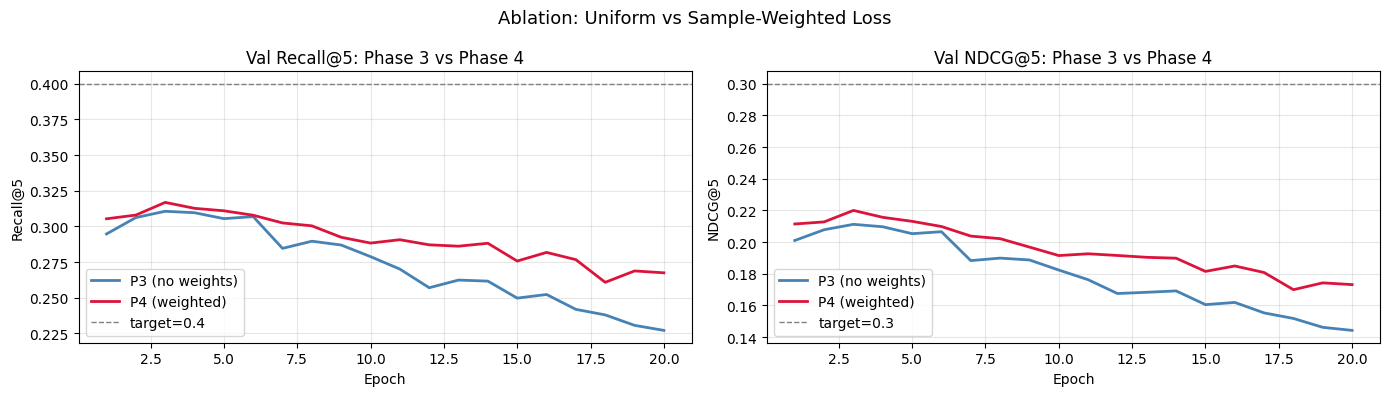


→ Phase 4 (weighted) selected for production inference.
   Production tower = phase4_weighted


In [20]:
# ── Phase 3 vs Phase 4 Comparison ──────────────────────────────
# Load best Phase 4 weights → evaluate on test set
student_tower_p4.load_weights(f"{CHECKPOINT_DIR_P4}/student_tower.weights.h5")
scholarship_tower_p4.load_weights(f"{CHECKPOINT_DIR_P4}/scholarship_tower.weights.h5")
print(f"Loaded Phase 4 best checkpoint (epoch {best_epoch_p4})")

test_metrics_p4    = compute_retrieval_metrics_p4(test_df)
test_metrics_p4_10 = compute_retrieval_metrics_p4(test_df, k=10)

# Phase 3 test results (from Cell 10)
p3_recall5  = test_metrics[f"Recall@5"]
p3_ndcg5    = test_metrics[f"NDCG@5"]
p3_mrr      = test_metrics["MRR"]
p3_recall10 = test_metrics_10["Recall@10"]

p4_recall5  = test_metrics_p4[f"Recall@5"]
p4_ndcg5    = test_metrics_p4[f"NDCG@5"]
p4_mrr      = test_metrics_p4["MRR"]
p4_recall10 = test_metrics_p4_10["Recall@10"]

print("\n╔══════════════════════════════════════════════════════════════╗")
print("║           Phase 3 vs Phase 4 — Test Set Comparison          ║")
print("╠══════════════════════╦══════════╦══════════╦════════════════╣")
print("║ Metric               ║ Phase 3  ║ Phase 4  ║ Delta          ║")
print("╠══════════════════════╬══════════╬══════════╬════════════════╣")
for name, p3, p4, target in [
    ("Recall@5  (target≥0.4)", p3_recall5,  p4_recall5,  0.40),
    ("NDCG@5    (target≥0.3)", p3_ndcg5,    p4_ndcg5,    0.30),
    ("MRR",                    p3_mrr,      p4_mrr,      None),
    ("Recall@10",              p3_recall10, p4_recall10, 0.40),
]:
    delta = p4 - p3
    sign  = "+" if delta >= 0 else ""
    tag   = ""
    if target is not None:
        tag = " ✓" if p4 >= target else " ✗"
    print(f"║ {name:<20} ║ {p3:.4f}   ║ {p4:.4f}   ║ {sign}{delta:.4f}{tag:<8}  ║")
print("╚══════════════════════╩══════════╩══════════╩════════════════╝")

# ── Comparison loss curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = history["epoch"]

axes[0].plot(epochs, history[f"val_Recall@{TOP_K}"],  label="P3 (no weights)", linewidth=2, color="steelblue")
axes[0].plot(epochs, history_p4[f"val_Recall@{TOP_K}"], label="P4 (weighted)", linewidth=2, color="crimson")
axes[0].axhline(0.4, color="gray", linestyle="--", linewidth=1, label="target=0.4")
axes[0].set_title(f"Val Recall@{TOP_K}: Phase 3 vs Phase 4")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Recall@5")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history[f"val_NDCG@{TOP_K}"],  label="P3 (no weights)", linewidth=2, color="steelblue")
axes[1].plot(epochs, history_p4[f"val_NDCG@{TOP_K}"], label="P4 (weighted)", linewidth=2, color="crimson")
axes[1].axhline(0.3, color="gray", linestyle="--", linewidth=1, label="target=0.3")
axes[1].set_title(f"Val NDCG@{TOP_K}: Phase 3 vs Phase 4")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("NDCG@5")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Ablation: Uniform vs Sample-Weighted Loss", fontsize=13)
plt.tight_layout()
plt.savefig(f"{LOG_DIR}/phase3_vs_phase4.png", dpi=120)
plt.show()

# Pick best phase for production
if p4_recall5 >= p3_recall5:
    print("\n→ Phase 4 (weighted) selected for production inference.")
    best_student_tower     = student_tower_p4
    best_scholarship_tower = scholarship_tower_p4
    best_phase_label       = "phase4_weighted"
else:
    print("\n→ Phase 3 (unweighted) selected for production inference.")
    best_student_tower     = student_tower
    best_scholarship_tower = scholarship_tower
    best_phase_label       = "phase3_unweighted"
print(f"   Production tower = {best_phase_label}")

## 14. Phase 5 — Save Production Embeddings

Setelah training selesai, simpan dua artefak untuk production inference:

| File | Shape | Isi |
|---|---|---|
| `checkpoints/two_tower_v2/student_tower.weights.h5` | — | Weights student tower (best phase) |
| `checkpoints/two_tower_v2/scholarship_emb_tower.npy` | (43, 128) | Pre-computed scholarship embeddings |

**Inference flow** (runtime):
1. Load `student_tower` weights + `scholarship_emb_tower.npy`
2. Per request: encode student features → student tower forward pass → 128-dim L2-normalized embedding
3. Dot product: `student_emb @ scholarship_emb_tower.T` → scores (43,)
4. `argsort` descending → top-K recommendation IDs

In [21]:
PROD_DIR = CHECKPOINT_DIR   # ./checkpoints/two_tower_v2/
os.makedirs(PROD_DIR, exist_ok=True)

# ── 1. Save scholarship embeddings (43 × 128) ──────────────────
sch_feat_all     = np.concatenate([sch_struct, scholarship_text_emb], axis=1)  # (43, 509)
sch_emb_prod     = best_scholarship_tower(sch_feat_all, training=False).numpy()  # (43, 128)

sch_emb_path = f"{PROD_DIR}/scholarship_emb_tower.npy"
np.save(sch_emb_path, sch_emb_prod)
print(f"Saved: {sch_emb_path}")
print(f"  shape : {sch_emb_prod.shape}   dtype={sch_emb_prod.dtype}")
print(f"  norms : min={np.linalg.norm(sch_emb_prod, axis=1).min():.6f} "
      f"max={np.linalg.norm(sch_emb_prod, axis=1).max():.6f}  (should be ≈1.0)")

# ── 2. Save best student tower weights ─────────────────────────
stu_weights_path = f"{PROD_DIR}/student_tower_prod.weights.h5"
best_student_tower.save_weights(stu_weights_path)
print(f"\nSaved: {stu_weights_path}")

# ── 3. Verify round-trip inference ─────────────────────────────
print("\n── Round-trip verification ──────────────────────────────────")
test_stu_id  = list(stu_id_to_idx.keys())[0]
idx          = stu_id_to_idx[test_stu_id]
stu_feat_rt  = np.concatenate([stu_struct[[idx]], student_text_emb[[idx]]], axis=1)
stu_emb_rt   = best_student_tower(stu_feat_rt, training=False).numpy()[0]          # (128,)

sch_emb_rt   = np.load(sch_emb_path)                                               # (43, 128)
scores_rt    = sch_emb_rt @ stu_emb_rt                                             # (43,)
top5_idx     = np.argsort(-scores_rt)[:5]
print(f"Student : {test_stu_id}")
print(f"Top-5 scholarships (dot product scores):")
for rank, i in enumerate(top5_idx, 1):
    name = scholarships_df.iloc[i]["name"]
    print(f"  #{rank}  {scores_rt[i]:.4f}  {name}")

print(f"\nPhase 5 complete — production artefacts in: {PROD_DIR}/")
print(f"  student_tower_prod.weights.h5    — load into student tower at inference")
print(f"  scholarship_emb_tower.npy        — pre-computed (43, 128), load once")

Saved: ./checkpoints/two_tower_v2/scholarship_emb_tower.npy
  shape : (43, 128)   dtype=float32
  norms : min=1.000000 max=1.000000  (should be ≈1.0)

Saved: ./checkpoints/two_tower_v2/student_tower_prod.weights.h5

── Round-trip verification ──────────────────────────────────
Student : STU_000000
Top-5 scholarships (dot product scores):
  #1  0.5575  UWC Scholarship (United World Colleges)
  #2  0.5375  AFS Intercultural Programs Scholarship
  #3  0.5367  Al-Azhar University Scholarship (Egypt)
  #4  0.4446  ASEAN Scholarship (Singapore)
  #5  0.4442  JPA Malaysia Overseas Scholarship (Undergraduate)

Phase 5 complete — production artefacts in: ./checkpoints/two_tower_v2/
  student_tower_prod.weights.h5    — load into student tower at inference
  scholarship_emb_tower.npy        — pre-computed (43, 128), load once
